## Homework 2

Answers for the **Homework 2** of the ML Zoomcamp 2026.

### Goal

The goal of this homework is to create a regression model for predicting the **car fuel efficiency** (column **`fuel_efficiency_mpg`**).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (3, 2)

### Getting the data

For this homework, the dataset used is the 2026 Car Fuel Efficiency dataset. It is available [here](https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv).



In [2]:
df_full = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')
df_full.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


### Preparing the dataset

Let's use only the following columns:
- `engine_displacement`,
- `horsepower`,
- `vehicle_weight`,
- `model_year`,
- `fuel_efficiency_mpg`


In [3]:
df = df_full[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]

### EDA

Let's look at the `fuel_efficiency_mpg` variable. Does it have a long tail?


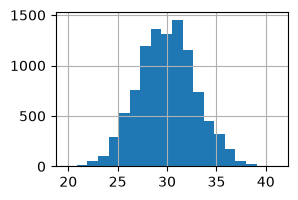

In [4]:
df['fuel_efficiency_mpg'].hist(bins=20)
plt.show()

### Question 1

There's one column with missing values. What is it?

- `engine_displacement`
- **`horsepower`** (it has `877` missing values)
- `vehicle_weight`
- `model_year`


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  10000 non-null  int64  
 1   horsepower           9123 non-null   float64
 2   vehicle_weight       10000 non-null  int64  
 3   model_year           10000 non-null  int64  
 4   fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


### Question 2

What's the median (50% percentile) for variable `horsepower`?

**= 254**

In [6]:
df['horsepower'].describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

In [7]:
print(df['horsepower'].median())

254.0


### Prepare and split the dataset

In this step let's shuffle the filtered dataset and create the split exactly as in the lecture:

In [8]:
# The following code is exactly as in the lecture.

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# y vectors for the linear regression model
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

### Question 3

- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model **LRM** without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 3 decimal digits using `round(score, 3)`. This keeps the imputation difference visible in this release.
- Which option gives better RMSE?

Options:

- With 0
- **With mean**
- Both are equally good

In [9]:
# Filling the missing values of horsepower with 0
df_train_mv0 = df_train.copy()
df_train_mv0['horsepower'] = df_train_mv0['horsepower'].fillna(0) # In the df_train

df_val_mv0 = df_val.copy()
df_val_mv0['horsepower'] = df_val_mv0['horsepower'].fillna(0) # In the df_val

# Filling the missing values of horsepower with the mean
df_train_mvm = df_train.copy()
df_train_mvm['horsepower'] = df_train_mvm['horsepower'].fillna(df_train['horsepower'].mean().item()) # In the df_train

df_val_mvm = df_val.copy()
df_val_mvm['horsepower'] = df_val_mvm['horsepower'].fillna(df_train['horsepower'].mean().item()) # In the df_val

In [10]:
# Defining the columns for the LRM
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

# X matrix values for df_train ('horsepower' missing values filled with 0)
X_train_mv0 = df_train_mv0[base].values # X_train
X_val_mv0 = df_val_mv0[base].values # X_val

# X matrix values for df_train ('horsepower' missing values filled with the mean)
X_train_mvm = df_train_mvm[base].values # X_train
X_val_mvm = df_val_mvm[base].values # X_val

In [11]:
# Function for training the LRM without regularization using the code from the lessons
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [12]:
# LRM for the X_train with missing values filled with 0
w0_mv0, w_mv0 = train_linear_regression(X_train_mv0, y_train)
y_pred_mv0 = w0_mv0 + X_train_mv0.dot(w_mv0)

# LRM for the X_train with missing values filled with the mean of horsepower
w0_mvm, w_mvm = train_linear_regression(X_train_mvm, y_train)
y_pred_mvm = w0_mvm + X_train_mvm.dot(w_mvm)

<Axes: ylabel='Count'>

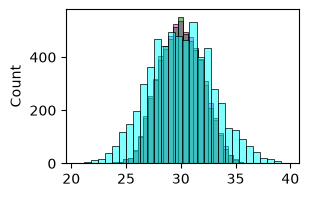

In [13]:
# Visualizing the predictions
sns.histplot(y_pred_mv0, color='magenta', alpha=0.5, bins=30)
sns.histplot(y_pred_mvm, color='green', alpha=0.5, bins=30)
sns.histplot(y_train, color='cyan', alpha=0.5, bins=30)

In [14]:
# Function for calculating the RMSE of the LRM
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [15]:
# Calculating the RMSE for the X_train matrix
rmse_mv0 = round(rmse(y_train, y_pred_mv0), 3) # For the model with 0 in missing values
rmse_mvm = round(rmse(y_train, y_pred_mvm), 3) # For the model with mean in missing values

print(f"RMSE for X_train filled with 0 in missing values: {rmse_mv0}")
print(f"RMSE for X_train filled with mean of horsepower in missing values: {rmse_mvm}")

RMSE for X_train filled with 0 in missing values: 2.2
RMSE for X_train filled with mean of horsepower in missing values: 2.198


In [16]:
# Using LRM for calculate y_pred on X_val
y_pred_mv0 = w0_mv0 + X_val_mv0.dot(w_mv0) # 'horsepower' missing values in X_val filled with 0
y_pred_mvm = w0_mvm + X_val_mvm.dot(w_mvm) # 'horsepower' missing values in X_val filled with mean

# Calculating the RMSE for both models
rmse_val_mv0 = round(rmse(y_val, y_pred_mv0), 3)
rmse_val_mvm = round(rmse(y_val, y_pred_mvm), 3)

print(f"RMSE for X_val filled with 0 in missing values: {rmse_val_mv0}")
print(f"RMSE for X_val filled with mean of horsepower in missing values: {rmse_val_mvm}")

RMSE for X_val filled with 0 in missing values: 2.205
RMSE for X_val filled with mean of horsepower in missing values: 2.202


**Answer Q3**: The option which gives better RMSE is **using the mean** for filling the missing values of the `horsepower` column in `df_train`.

### Question 4

- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
- Which r gives the best RMSE?

If multiple options give the same best RMSE, select the smallest r.

Options:

- **0**
- 0.01
- 0.1
- 1
- 5
- 10
- 100

In [17]:
# First, let's fill the NAs with 0 in df_train & df_val
df_train_reg = df_train.fillna(0)
df_val_reg = df_val.fillna(0)

# Defining the columns for the LRM with regularization
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

# X matrix values for df_train ('horsepower' missing values filled with 0)
X_train_reg = df_train_reg[base].values
X_val_reg = df_val_reg[base].values

In [18]:
# Function for LRM with regularization (same as in the lessons)
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [19]:
# Trying diferents values of r for 
r = [0, 0.01, 0.1, 1, 5, 10, 100]
rmse_reg = []

for reg in r:
    w0, w = train_linear_regression_reg(X_train_reg, y_train, reg)
    y_pred_reg = w0 + X_val_reg.dot(w)
    rmse_calc = round(rmse(y_val, y_pred_reg), 4)
    rmse_reg.append(rmse_calc)

for k in range(len(r)):
    print(f"RMSE for r={r[k]}:    \t{rmse_reg[k]}")

RMSE for r=0:    	2.2053
RMSE for r=0.01:    	2.2058
RMSE for r=0.1:    	2.2241
RMSE for r=1:    	2.3492
RMSE for r=5:    	2.4094
RMSE for r=10:    	2.4195
RMSE for r=100:    	2.4292


**Answer Q4**: The `r` which gives the best RMSE is **`0`**.

### Question 5

- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

What's the value of std?

- 0.006
- 0.016
- **0.029**
- 0.036




In [ ]:
# Let's define the variable the different seeds
seed_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# Defining the columns for the X matrixes
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

# Defining the list for storing the different RMSE values
rmse_seeds = []

# Parameters for splitting df
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

for s in seed_values:
    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train_s = df.iloc[idx[:n_train]]
    df_val_s = df.iloc[idx[n_train:n_train + n_val]]
    df_test_s = df.iloc[idx[n_train + n_val:]]

    df_train_s = df_train_s.fillna(0)
    df_val_s = df_val_s.fillna(0)

    df_train_s = df_train_s.reset_index(drop=True)
    df_val_s = df_val_s.reset_index(drop=True)
    df_test_s = df_test_s.reset_index(drop=True)

    # y vectors for the linear regression model
    y_train_s = df_train_s['fuel_efficiency_mpg'].values
    y_val_s = df_val_s['fuel_efficiency_mpg'].values
    
    # X matrixes
    X_train_s = df_train_s[base].values
    X_val_s = df_val_s[base].values

    w0, w = train_linear_regression(X_train_s, y_train_s)
    y_pred_s = w0 + X_val_s.dot(w)
    rmse_calc = round(rmse(y_val_s, y_pred_s), 4)
    rmse_seeds.append(rmse_calc)

In [ ]:
# Calculating the standard deviation of all RMSE
round(np.std(rmse_seeds), 3)

np.float64(0.029)

**Answer Q5**: The standard deviation of all RMSE is **0.029**.

### Question 6

- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.
- What's the RMSE on the test dataset?

Options:

- 0.236
- **2.236**
- 22.10
- 221.0

In [27]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train_s9 = df.iloc[idx[:n_train]]
df_val_s9 = df.iloc[idx[n_train:n_train + n_val]]
df_test_s9 = df.iloc[idx[n_train + n_val:]]

# Combining train and validation datasets
df_train_Q6 = pd.concat([df_train_s9, df_val_s9])

# Filling the missing values with 0
df_train_Q6 = df_train_Q6.fillna(0)
df_test_Q6 = df_test_s9.fillna(0)

df_train_Q6 = df_train_Q6.reset_index(drop=True)
df_test_Q6 = df_test_Q6.reset_index(drop=True)

base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

# X matrixes
X_train_Q6 = df_train_Q6[base].values
X_test_Q6 = df_test_Q6[base].values

# y vectors for the linear regression model
y_train_Q6 = df_train_Q6['fuel_efficiency_mpg'].values
y_test_Q6 = df_test_Q6['fuel_efficiency_mpg'].values

w0, w = train_linear_regression_reg(X_train_Q6, y_train_Q6, 0.001)
y_pred_Q6 = w0 + X_test_Q6.dot(w)
rmse_Q6 = round(rmse(y_test_Q6, y_pred_Q6), 3)

print(f"RMSE= {rmse_Q6}")

RMSE= 2.236


**Answer Q6**: The RMSE on the test datset is **2.236**.